In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_hub as hub
from scipy.signal import spectrogram

In [12]:
model_url="https://tfhub.dev/google/yamnet/1"
yamnet_model=hub.load(model_url)

In [13]:
def load_audio(audio_file_path):
    audio = tf.io.read_file(audio_file_path)
    audio, sample_rate = tf.audio.decode_wav(audio)
    return tf.squeeze(audio, axis=1), sample_rate

In [14]:
audio_file_path= 'Voice.wav'
waveform,sample_rate=load_audio(audio_file_path)

Sample rate: 48000
Waveform shape: (209844,)


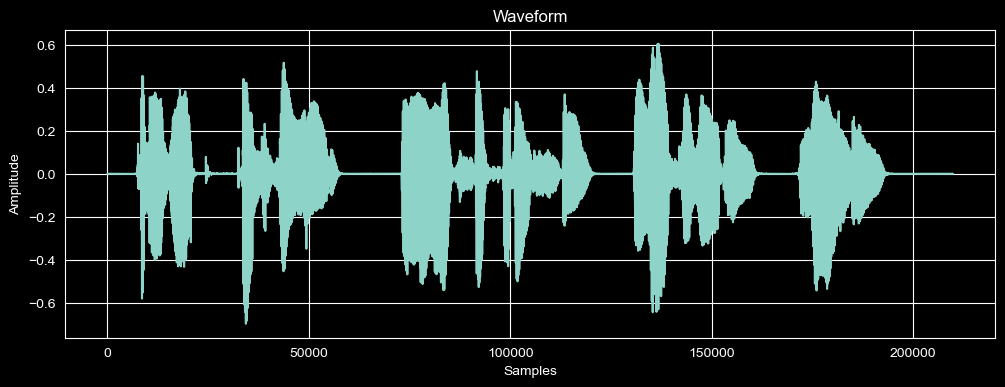

In [15]:
print(f"Sample rate: {sample_rate.numpy()}")
print(f"Waveform shape: {waveform.shape}")

plt.figure(figsize=(12, 4))
plt.plot(waveform.numpy())
plt.title("Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [16]:
class_map_path=yamnet_model.class_map_path().numpy().decode("utf-8")
class_names=np.array([name for name in open(class_map_path).read().splitlines()])

In [17]:
def predict(audio):
    scores,embeddings,spectrogram=yamnet_model(audio)
    scores_np=scores.numpy()
    return scores_np

In [18]:
scores = predict(waveform)

In [19]:
predicted_class=class_names[scores.mean(axis=0).argmax()]
print(predicted_class)

index,mid,display_name


In [22]:
for i in range(len(class_names)):
    print(f"{class_names[i]}: {scores.mean(axis=0)[i]}")

index,mid,display_name: 0.24294649064540863
0,/m/09x0r,Speech: 0.00045351695735007524
1,/m/0ytgt,"Child speech, kid speaking": 0.004660625476390123
2,/m/01h8n0,Conversation: 0.008861386217176914
3,/m/02qldy,"Narration, monologue": 2.2147921185933228e-07
4,/m/0261r1,Babbling: 0.014982267282903194
5,/m/0brhx,Speech synthesizer: 0.00024800249957479537
6,/m/07p6fty,Shout: 0.00023555730876978487
7,/m/07q4ntr,Bellow: 7.542428647866473e-05
8,/m/07rwj3x,Whoop: 1.139748655987205e-05
9,/m/07sr1lc,Yell: 1.0968592700777435e-09
10,/t/dd00135,Children shouting: 4.6003326133359224e-05
11,/m/03qc9zr,Screaming: 6.159465556265786e-05
12,/m/02rtxlg,Whispering: 0.00018967039068229496
13,/m/01j3sz,Laughter: 4.152376931187973e-08
14,/t/dd00001,Baby laughter: 5.631156909657875e-07
15,/m/07r660_,Giggle: 1.1802889275713824e-05
16,/m/07s04w4,Snicker: 3.588575125945681e-08
17,/m/07sq110,Belly laugh: 4.4166627048980445e-05
18,/m/07rgt08,"Chuckle, chortle": 0.00011315671872580424
19,/m/0463cq4,"Crying, sobbing": 1

IndexError: index 521 is out of bounds for axis 0 with size 521